# 1 — Imports & Environment Check

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models

from tqdm.auto import tqdm

# Confirm GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
PyTorch version: 2.10.0+cu128


# 2 — Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR = Path("/kaggle/input/notebooks/miguelmirandar/02-data-preparation")          # where train/val/test CSVs live
IMAGE_DIR = Path("/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/images/images")
CKPT_DIR  = Path("/kaggle/working/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Task definition ─────────────────────────────────────────────────────────
TASKS = {
    "sleeve_length": 5,   # classes 0-4  (NA=5 excluded)
    "upper_fabric":  7,   # classes 0-6  (NA=7 excluded)
    "upper_color":   7,   # classes 0-6  (NA=7 excluded)
}

# ── Hyperparameters ─────────────────────────────────────────────────────────
CFG = {
    "img_size":      224,
    "batch_size":    64,
    "num_workers":   2,
    "epochs":        20,
    "lr":            3e-4,
    "weight_decay":  1e-2,
    "label_smoothing": 0.1,
    "seed":          42,
}

print("Tasks:", TASKS)
print("Config:", CFG)
print(f"Checkpoint dir: {CKPT_DIR}")

Tasks: {'sleeve_length': 5, 'upper_fabric': 7, 'upper_color': 7}
Config: {'img_size': 224, 'batch_size': 64, 'num_workers': 2, 'epochs': 20, 'lr': 0.0003, 'weight_decay': 0.01, 'label_smoothing': 0.1, 'seed': 42}
Checkpoint dir: /kaggle/working/checkpoints


# 3 — Reproducibility & Class Weights

In [4]:
import random

def seed_everything(seed: int):
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG["seed"])

# ── Load class weights saved in Notebook 02 ─────────────────────────────────
weights = torch.load(DATA_DIR / "class_weights.pt", map_location=device)

# Expected keys: "sleeve_length", "upper_fabric", "upper_color"
print("Class weights loaded:")
for task, w in weights.items():
    print(f"  {task}: {w.tolist()}")

Class weights loaded:
  sleeve_length: [0.014153027907013893, 0.02705385535955429, 0.10925548523664474, 0.018260177224874496, 4.831277370452881]
  upper_fabric: [0.4429211914539337, 0.0062790000811219215, 2.4412167072296143, 1.5904897451400757, 0.09108227491378784, 0.04227640852332115, 2.3857345581054688]
  upper_color: [1.0036793947219849, 0.13344000279903412, 0.645506739616394, 0.07316052168607712, 1.928871989250183, 1.4419556856155396, 1.7733856439590454]


# 4 — Dataset & DataLoaders

In [5]:
import torchvision.transforms as T
from torch.utils.data import Dataset
from PIL import Image

# ── Dataset class ────────────────────────────────────────────────────────────
class GarmentDataset(Dataset):
    """Loads garment images and returns (image, labels_dict) pairs."""

    def __init__(self, csv_path, image_dir, transform=None):
        self.df        = pd.read_csv(csv_path)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.image_dir / row["image_name"]
        image    = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = {
            "sleeve_length": torch.tensor(row["sleeve_length"], dtype=torch.long),
            "upper_fabric":  torch.tensor(row["upper_fabric"],  dtype=torch.long),
            "upper_color":   torch.tensor(row["upper_color"],   dtype=torch.long),
        }
        return image, labels


# ── Transforms ───────────────────────────────────────────────────────────────
def get_transforms(split: str, img_size: int):
    """Returns transforms for train (with augmentation) or val/test."""
    if split == "train":
        return T.Compose([
            T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])
    else:
        return T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])


# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = GarmentDataset(DATA_DIR / "train.csv", IMAGE_DIR, get_transforms("train", CFG["img_size"]))
val_ds   = GarmentDataset(DATA_DIR / "val.csv",   IMAGE_DIR, get_transforms("val",   CFG["img_size"]))

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)

print(f"Train samples : {len(train_ds):,}")
print(f"Val samples   : {len(val_ds):,}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

# Sanity check — load one batch
imgs, labels = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")
print(f"sleeve_length     : {labels['sleeve_length'][:8].tolist()}")
print(f"upper_fabric      : {labels['upper_fabric'][:8].tolist()}")
print(f"upper_color       : {labels['upper_color'][:8].tolist()}")

Train samples : 29,040
Val samples   : 6,223
Train batches : 454
Val batches   : 98

Batch image shape : torch.Size([64, 3, 224, 224])
sleeve_length     : [0, 3, 3, 0, 2, 1, 0, 0]
upper_fabric      : [1, 1, 0, 1, 1, 1, 5, 5]
upper_color       : [1, 3, 3, 3, 1, 3, 1, 3]


# 5 — Model Architecture

In [6]:
import torchvision.models as models

class GarmentClassifier(nn.Module):
    """
    EfficientNet-B0 backbone with 3 parallel classification heads:
      - sleeve_length (5 classes)
      - upper_fabric  (7 classes)
      - upper_color   (7 classes)
    """

    def __init__(self, tasks: dict):
        super().__init__()

        # ── Backbone: EfficientNet-B0 pretrained on ImageNet ─────────────────
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

        # Remove the original classifier, keep only the feature extractor
        self.features = backbone.features
        self.avgpool  = backbone.avgpool  # AdaptiveAvgPool2d → (1, 1)

        in_features = backbone.classifier[1].in_features  # 1280 for B0

        # ── One classification head per task ─────────────────────────────────
        self.heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Dropout(p=0.3),
                nn.Linear(in_features, num_classes),
            )
            for task, num_classes in tasks.items()
        })

    def forward(self, x):
        # Extract features
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)  # (batch, 1280)

        # Each head produces its own logits
        return {task: head(x) for task, head in self.heads.items()}


# ── Instantiate & move to device ─────────────────────────────────────────────
model = GarmentClassifier(TASKS).to(device)

# Parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Sanity check — forward pass with one batch
with torch.no_grad():
    sample_imgs = imgs.to(device)
    outputs = model(sample_imgs)
    for task, logits in outputs.items():
        print(f"{task} logits shape: {logits.shape}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]


Total parameters    : 4,031,887
Trainable parameters: 4,031,887
sleeve_length logits shape: torch.Size([64, 5])
upper_fabric logits shape: torch.Size([64, 7])
upper_color logits shape: torch.Size([64, 7])


# 6 — Loss, Optimizer & Scheduler

In [7]:
# ── One weighted CrossEntropy loss per task ───────────────────────────────────
criteria = {
    task: nn.CrossEntropyLoss(
        weight=weights[task].to(device),
        label_smoothing=CFG["label_smoothing"]
    )
    for task in TASKS
}

# ── AdamW optimizer — all parameters ─────────────────────────────────────────
optimizer = AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)

# ── Cosine annealing: lr decays smoothly from lr → 0 over all epochs ─────────
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=CFG["epochs"],
    eta_min=1e-6
)

print("Criteria:")
for task, criterion in criteria.items():
    print(f"  {task}: CrossEntropyLoss(weight={weights[task].tolist()}, label_smoothing={CFG['label_smoothing']})")
print(f"\nOptimizer : AdamW(lr={CFG['lr']}, weight_decay={CFG['weight_decay']})")
print(f"Scheduler : CosineAnnealingLR(T_max={CFG['epochs']}, eta_min=1e-6)")

Criteria:
  sleeve_length: CrossEntropyLoss(weight=[0.014153027907013893, 0.02705385535955429, 0.10925548523664474, 0.018260177224874496, 4.831277370452881], label_smoothing=0.1)
  upper_fabric: CrossEntropyLoss(weight=[0.4429211914539337, 0.0062790000811219215, 2.4412167072296143, 1.5904897451400757, 0.09108227491378784, 0.04227640852332115, 2.3857345581054688], label_smoothing=0.1)
  upper_color: CrossEntropyLoss(weight=[1.0036793947219849, 0.13344000279903412, 0.645506739616394, 0.07316052168607712, 1.928871989250183, 1.4419556856155396, 1.7733856439590454], label_smoothing=0.1)

Optimizer : AdamW(lr=0.0003, weight_decay=0.01)
Scheduler : CosineAnnealingLR(T_max=20, eta_min=1e-6)


# 7 — Training & Validation Functions

In [9]:
def train_epoch(model, loader, criteria, optimizer, device):
    """One full pass over the training set. Returns avg loss and per-task accuracy."""
    model.train()

    total_loss = 0.0
    correct    = {task: 0 for task in TASKS}
    total      = 0

    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device)
        labels = {task: labels[task].to(device) for task in TASKS}

        optimizer.zero_grad()

        outputs = model(imgs)

        # Sum losses from all 3 heads
        loss = sum(criteria[task](outputs[task], labels[task]) for task in TASKS)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)

        for task in TASKS:
            preds = outputs[task].argmax(dim=1)
            correct[task] += (preds == labels[task]).sum().item()

    avg_loss = total_loss / total
    acc      = {task: correct[task] / total for task in TASKS}
    return avg_loss, acc


def val_epoch(model, loader, criteria, device):
    """One full pass over the validation set. Returns avg loss and per-task accuracy."""
    model.eval()

    total_loss = 0.0
    correct    = {task: 0 for task in TASKS}
    total      = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Val", leave=False):
            imgs   = imgs.to(device)
            labels = {task: labels[task].to(device) for task in TASKS}

            outputs = model(imgs)

            loss = sum(criteria[task](outputs[task], labels[task]) for task in TASKS)

            total_loss += loss.item() * imgs.size(0)
            total      += imgs.size(0)

            for task in TASKS:
                preds = outputs[task].argmax(dim=1)
                correct[task] += (preds == labels[task]).sum().item()

    avg_loss = total_loss / total
    acc      = {task: correct[task] / total for task in TASKS}
    return avg_loss, acc


print("train_epoch and val_epoch defined.")

train_epoch and val_epoch defined.


# 8 — Training Loop

In [10]:
history = []
best_val_loss = float("inf")

for epoch in range(1, CFG["epochs"] + 1):

    # ── Train ────────────────────────────────────────────────────────────────
    train_loss, train_acc = train_epoch(model, train_loader, criteria, optimizer, device)

    # ── Validate ─────────────────────────────────────────────────────────────
    val_loss, val_acc = val_epoch(model, val_loader, criteria, device)

    # ── Scheduler step ───────────────────────────────────────────────────────
    scheduler.step()

    # ── Log ──────────────────────────────────────────────────────────────────
    history.append({
        "epoch":               epoch,
        "train_loss":          train_loss,
        "val_loss":            val_loss,
        "train_acc_sleeve":    train_acc["sleeve_length"],
        "train_acc_fabric":    train_acc["upper_fabric"],
        "train_acc_color":     train_acc["upper_color"],
        "val_acc_sleeve":      val_acc["sleeve_length"],
        "val_acc_fabric":      val_acc["upper_fabric"],
        "val_acc_color":       val_acc["upper_color"],
    })

    print(
        f"Epoch {epoch:02d}/{CFG['epochs']} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc — sleeve: {val_acc['sleeve_length']:.3f} "
        f"fabric: {val_acc['upper_fabric']:.3f} "
        f"color: {val_acc['upper_color']:.3f}"
    )

    # ── Save best model ───────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch":             epoch,
            "model_state_dict":  model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":          val_loss,
            "val_acc":           val_acc,
            "cfg":               CFG,
        }, CKPT_DIR / "best_model.pt")
        print(f"  ✅ Best model saved (val_loss={val_loss:.4f})")

print("\nTraining complete.")

Train:   0%|          | 0/454 [00:00<?, ?it/s]

Val:   0%|          | 0/98 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78788c715a80>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78788c715a80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1653, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.12/threading.py", line 1146, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread


<function _MultiProcessingDataLoaderIter.__del__ at 0x78788c715a80>Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", l

Epoch 01/20 | Train loss: 12.8508 | Val loss: 12.3492 | Val acc — sleeve: 0.002 fabric: 0.028 color: 0.494
  ✅ Best model saved (val_loss=12.3492)


Train:   0%|          | 0/454 [00:00<?, ?it/s]

...

Epoch 19/20 | Train loss: 10.8515 | Val loss: 11.6884 | Val acc — sleeve: 0.018 fabric: 0.086 color: 0.868


Train:   0%|          | 0/454 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78788c715a80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x78788c715a80>
^^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^^^self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():
^ ^ ^^  ^^ ^ ^

Val:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 20/20 | Train loss: 10.9641 | Val loss: 11.6772 | Val acc — sleeve: 0.016 fabric: 0.088 color: 0.871

Training complete.


# 9 — Training Curves

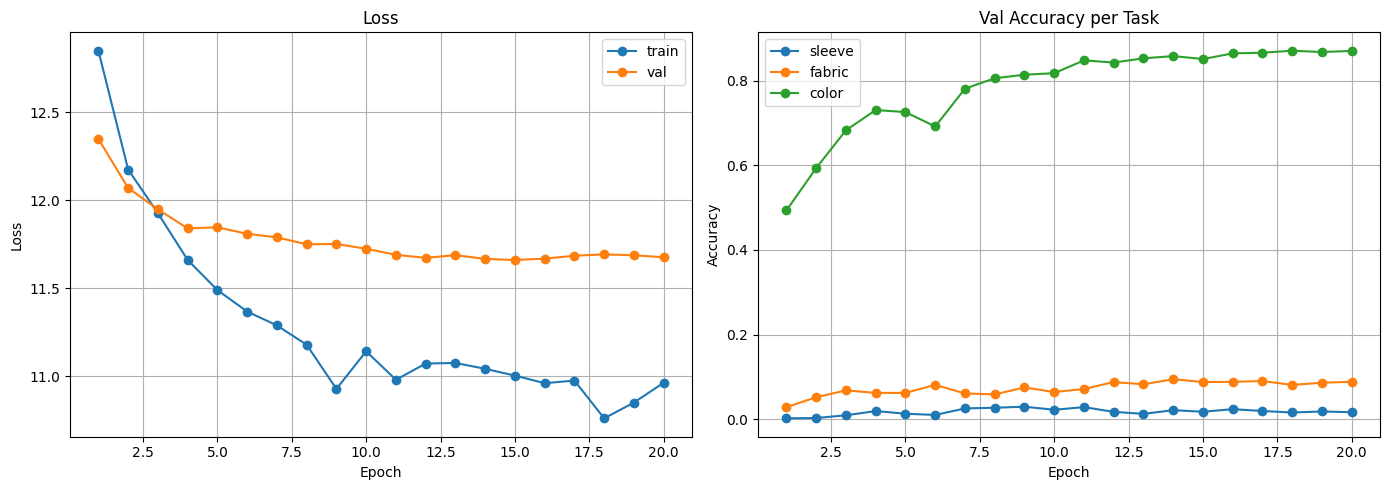

Saved: training_curves.png, training_history.csv
 epoch  train_loss  val_loss  val_acc_sleeve  val_acc_fabric  val_acc_color
     1   12.850784 12.349166        0.001928        0.028282       0.493653
     2   12.175039 12.070743        0.002732        0.051904       0.593765
     3   11.927639 11.949419        0.009160        0.067974       0.683111
     4   11.661829 11.841445        0.019123        0.062189       0.730837
     5   11.490483 11.847017        0.012856        0.062028       0.726016
     6   11.368873 11.810733        0.009963        0.081151       0.691949
     7   11.289788 11.790068        0.025390        0.060742       0.781456
     8   11.179872 11.750975        0.026997        0.058493       0.806042
     9   10.929156 11.752648        0.029407        0.075044       0.814398
    10   11.142900 11.725550        0.022176        0.064117       0.817933
    11   10.980996 11.691038        0.028443        0.071348       0.848305
    12   11.073322 11.673634        0.0

In [12]:
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss ─────────────────────────────────────────────────────────────────────
axes[0].plot(df_hist["epoch"], df_hist["train_loss"], label="train", marker="o")
axes[0].plot(df_hist["epoch"], df_hist["val_loss"],   label="val",   marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# ── Accuracy per task ─────────────────────────────────────────────────────────
axes[1].plot(df_hist["epoch"], df_hist["val_acc_sleeve"], label="sleeve", marker="o")
axes[1].plot(df_hist["epoch"], df_hist["val_acc_fabric"], label="fabric", marker="o")
axes[1].plot(df_hist["epoch"], df_hist["val_acc_color"],  label="color",  marker="o")
axes[1].set_title("Val Accuracy per Task")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

# Save history to CSV
df_hist.to_csv("/kaggle/working/training_history.csv", index=False)
print("Saved: training_curves.png, training_history.csv")
print(df_hist[["epoch","train_loss","val_loss","val_acc_sleeve","val_acc_fabric","val_acc_color"]].to_string(index=False))

# 10 — Verify best model checkpoint

In [13]:
checkpoint = torch.load(CKPT_DIR / "best_model.pt", map_location=device)

print(f"Best model saved at epoch : {checkpoint['epoch']}")
print(f"Val loss                  : {checkpoint['val_loss']:.4f}")
print("Val acc:")
for task, acc in checkpoint["val_acc"].items():
    print(f"  {task}: {acc:.4f}")

Best model saved at epoch : 15
Val loss                  : 11.6618
Val acc:
  sleeve_length: 0.0175
  upper_fabric: 0.0877
  upper_color: 0.8514
